# OpenBCI Ganglion 실습 1 · 근전도(EMG) 신호 다루기

**재활재생개론 · 근육이 내는 전기 신호를 측정하고 처리하기**

---

## 이 실습에서 하는 일

| 단계 | 내용 |
| --- | --- |
| 1 | BLED112 동글로 Ganglion 보드에 연결 |
| 2 | 팔 근육의 **근전도(EMG)** 신호 수집 |
| 3 | 필터링 — 잡음 제거 |
| 4 | RMS · 주파수 분석 |
| 5 | 그래프로 확인하고 CSV로 저장 |

## 준비물

- **OpenBCI Ganglion 보드** (전원 ON)
- **BLED112 USB 동글** (COM 포트에 연결)
- **EMG 전극** — 팔뚝에 붙일 것

## 근전도(EMG)란

근육이 수축할 때 근섬유에서 발생하는 **전기 신호**입니다.
피부에 전극을 붙이면 그 아래 근육의 활동을 전압으로 읽을 수 있습니다.

| | 값 |
| --- | --- |
| 진폭 | 수십 µV ~ 수 mV (뇌파보다 훨씬 큼) |
| 주요 주파수 | 20 ~ 450 Hz (에너지는 50~150 Hz 부근에 집중) |
| 특징 | 힘을 줄수록 진폭이 커진다 |

## ⚠️ 이 실습은 EMG 전용입니다

이 프로젝트는 **근전도만** 다룹니다. 뇌파(EEG)는 다루지 않습니다.

같은 Ganglion 보드로 뇌파도 잴 수 있지만, **전극을 어디에 붙이고
어떤 주파수를 남기느냐**가 완전히 다릅니다. 여기서는 팔 근육에 붙이고
EMG 대역만 남깁니다.

> BrainFlow 함수 이름에 `eeg` 가 들어가는 것들이 있는데(`get_eeg_channels`),
> 이는 라이브러리가 생체전위 채널을 통칭하는 이름일 뿐입니다.
> **우리는 그 채널을 EMG 측정에 사용합니다.**

## Ganglion 보드 사양

| 항목 | 값 |
| --- | --- |
| 채널 수 | **4개** |
| 샘플링 레이트 | **200 Hz** |
| 볼 수 있는 최대 주파수 | **100 Hz** (= 200 ÷ 2, 나이퀴스트) |
| 통신 | BLE (BLED112 동글 경유) |

> ⚠️ EMG 는 원래 450 Hz 까지 성분이 있지만, 200 Hz 로 측정하면
> **100 Hz 까지만** 볼 수 있습니다. 손동작 판별처럼 **신호의 세기**를
> 쓰는 용도에는 충분합니다. 이 한계는 12단계에서 다시 다룹니다.

---

> ⚠️ **OpenBCI GUI 를 반드시 종료하세요.**
> 동글은 한 번에 한 프로그램만 사용할 수 있습니다.

**위에서 아래로 셀을 하나씩 실행하세요.** (`Shift + Enter`)

---
# 1단계 · 라이브러리 준비

필요한 도구를 불러옵니다.

**BrainFlow**는 OpenBCI 공식 라이브러리로, OpenBCI GUI도 내부적으로 이것을 사용합니다.
우리가 직접 통신 프로토콜을 구현할 필요 없이 보드와 대화할 수 있게 해 줍니다.

> 처음 실행한다면 아래 셀이 자동으로 `brainflow`를 설치합니다 (1~2분).

In [1]:
import sys
import subprocess
import warnings
from importlib.metadata import version as _pkg_version, PackageNotFoundError

# 콘솔에서 한글과 µ 기호가 깨지지 않도록 (Windows cp949 대응)
try:
    sys.stdout.reconfigure(encoding='utf-8')
except Exception:
    pass

warnings.filterwarnings('ignore', message='pkg_resources is deprecated')

# ─────────────────────────────────────────────────────────────
# brainflow 는 반드시 5.20.0 이어야 한다.
#
# 최신 brainflow(5.21+)는 BLED112 동글 지원이 죽어 있어서
# 연결 시도가 0초 만에 실패한다.
#
# 주의: 디스크의 버전이 맞아도, 커널이 예전 버전을 메모리에 들고 있으면
#       여전히 실패한다. 그래서 실제 로드된 DLL 버전까지 확인한다.
# ─────────────────────────────────────────────────────────────
REQUIRED_BF = '5.20.0'
_need_restart = False

try:
    _disk_bf = _pkg_version('brainflow')
except PackageNotFoundError:
    _disk_bf = None

# (1) 디스크에 설치된 버전이 다르면 맞춰 설치
if _disk_bf != REQUIRED_BF:
    print(f'brainflow 버전 조정: {_disk_bf} -> {REQUIRED_BF}')
    print('1~2분 걸립니다...')
    _cmd = [sys.executable, '-m', 'pip', 'install', '-q', f'brainflow=={REQUIRED_BF}']
    try:
        import pkg_resources          # 5.20.0 이 이걸 사용한다
    except ImportError:
        _cmd.append('setuptools<81')  # 없을 때만 함께 설치
    subprocess.check_call(_cmd)
    print('설치 완료')
    if 'brainflow' in sys.modules:
        _need_restart = True

# (2) 이미 메모리에 올라온 DLL 이 다른 버전인지 확인
if 'brainflow' in sys.modules and not _need_restart:
    try:
        from brainflow.board_shim import BoardShim as _BS
        if _BS.get_version() != REQUIRED_BF:
            _need_restart = True
    except Exception:
        _need_restart = True

if _need_restart:
    print()
    print('!' * 62)
    print('  커널을 재시작해야 합니다.')
    print()
    print('  메모리에 예전 버전이 남아 있어서, 이대로 진행하면')
    print('  연결이 0초 만에 실패합니다.')
    print()
    print('    메뉴에서  Kernel > Restart Kernel  실행')
    print('    그 다음 이 셀부터 다시 실행하세요.')
    print('!' * 62)
    raise SystemExit

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy import signal as sp_signal

from brainflow.board_shim import BoardShim, BrainFlowInputParams, BoardIds

# 그래프 한글 표시 - 설치된 한글 폰트 중 먼저 발견되는 것을 사용
from matplotlib import font_manager
_installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
_korean_font = '(없음)'
for _cand in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans KR', 'Gulim']:
    if _cand in _installed_fonts:
        plt.rcParams['font.family'] = _cand
        _korean_font = _cand
        break
plt.rcParams['axes.unicode_minus'] = False   # 음수 부호가 네모로 깨지는 것 방지

_loaded_bf = BoardShim.get_version()

print('준비 완료')
print(f'  Python    : {sys.version.split()[0]}')
print(f'  BrainFlow : {_loaded_bf}   (실제 로드된 버전)')
print(f'  NumPy     : {np.__version__}')
print(f'  SciPy     : {__import__("scipy").__version__}')
print(f'  한글 폰트 : {_korean_font}')

if _loaded_bf != REQUIRED_BF:
    print()
    print(f'경고: BrainFlow 가 {REQUIRED_BF} 이 아닙니다. 연결이 실패할 것입니다.')
    print('     Kernel > Restart Kernel 후 이 셀부터 다시 실행하세요.')

준비 완료
  Python    : 3.13.14
  BrainFlow : 5.20.0   (실제 로드된 버전)
  NumPy     : 2.4.3
  SciPy     : 1.17.1
  한글 폰트 : Malgun Gothic


---
# 2단계 · 동글이 꽂힌 COM 포트 찾기

BLED112 동글은 컴퓨터에 **가상 시리얼 포트**(COM3, COM4 …)로 나타납니다.
OpenBCI GUI에서 선택했던 것과 **같은 포트 번호**를 쓰면 됩니다.

아래 셀이 후보를 찾아 줍니다. 보통 이름에 `Bluetooth` 또는 `CP210x`가 들어갑니다.

In [3]:
try:
    from serial.tools import list_ports
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pyserial'])
    from serial.tools import list_ports

ports = list(list_ports.comports())

print('연결된 COM 포트')
print('=' * 60)

if not ports:
    print('포트를 찾지 못했습니다.')
    print('  -> BLED112 동글이 USB 에 꽂혀 있는지 확인하세요.')
else:
    for p in ports:
        # 동글일 가능성이 높은 포트에 표시
        desc = (p.description or '').lower()
        hint = '  <-- 동글일 가능성 높음' if ('bluetooth' in desc or 'cp210' in desc) else ''
        print(f'  {p.device:<8} {p.description}{hint}')

print('=' * 60)
print('위 목록에서 동글의 포트 번호를 확인하고, 다음 셀에 적으세요.')

연결된 COM 포트
  COM1     통신 포트(COM1)
  COM3     USB 직렬 장치(COM3)
위 목록에서 동글의 포트 번호를 확인하고, 다음 셀에 적으세요.


---
# 3단계 · 설정 ⭐ **여기만 고치면 됩니다**

이 노트북에서 **학생이 직접 수정하는 곳은 이 셀 하나뿐**입니다.

### `COM_PORT`
2단계에서 확인한 동글 포트. OpenBCI GUI에서 쓰던 것과 같은 번호.

### `BOARD_MAC` — 어떤 Ganglion 보드에 연결할지 지정

| 상황 | 설정값 |
| --- | --- |
| 주변에 Ganglion이 **내 것 하나뿐** | `''` (빈 문자열) → 자동으로 찾음 |
| **강의실처럼 여러 보드**가 켜져 있음 | 내 보드의 MAC 주소를 입력 ← **필수** |

> ⚠️ 여러 보드가 동시에 켜져 있는데 비워 두면 **옆 사람 보드에 연결될 수 있습니다.**
> 강의실에서는 반드시 MAC 주소를 지정하세요.

MAC 주소를 모른다면 → **4단계**에서 찾는 방법을 안내합니다. 일단 `''`로 두고 진행해도 됩니다.

### `DURATION_SEC`
몇 초 동안 신호를 모을지. 처음에는 10초를 권장합니다.

In [4]:
# ===================== 학생 설정 구역 =====================

COM_PORT     = 'COM3'      # 동글 포트

BOARD_MAC    = ''          # 비워 두세요.
                           # BLED112 동글 방식은 MAC 을 지정해도 무시됩니다.
                           # 여러 보드 대처법은 아래 스캔 셀 설명 참고

DURATION_SEC = 10          # 수집 시간 (초)

# ==========================================================

BOARD_ID = BoardIds.GANGLION_BOARD   # BLED112 동글용 Ganglion (board_id = 1)

print('설정 확인')
print('=' * 60)
print(f'  동글 포트   : {COM_PORT}')
print(f'  대상 보드   : 「내 보드 확인」 셀에서 결정')
print(f'  수집 시간   : {DURATION_SEC} 초')
print('=' * 60)

print()
print('다음 단계로 진행하기 전에 「내 보드 확인」 셀을 반드시 실행하세요.')
print('켜져 있는 Ganglion 이 1대일 때만 연결이 허용됩니다.')

설정 확인
  동글 포트   : COM3
  대상 보드   : 「내 보드 확인」 셀에서 결정
  수집 시간   : 10 초

다음 단계로 진행하기 전에 「내 보드 확인」 셀을 반드시 실행하세요.
켜져 있는 Ganglion 이 1대일 때만 연결이 허용됩니다.


---
# 4단계 · 보드 사양 확인 (연결 없이)

BrainFlow는 보드에 연결하지 않아도 사양을 알려줍니다.
**내가 다루는 신호가 몇 채널이고 초당 몇 개인지** 먼저 확인하는 습관을 들이세요.

이 값들은 뒤의 모든 분석(필터 설계, 주파수 축)의 기준이 됩니다.

> `get_eeg_channels()` 라는 이름이지만, BrainFlow 가 생체전위 채널을
> 통칭하는 표현입니다. **우리는 이 채널들을 EMG 측정에 씁니다.**

In [5]:
FS          = BoardShim.get_sampling_rate(BOARD_ID)   # 샘플링 레이트 (Hz)
EMG_CHANNELS = BoardShim.get_emg_channels(BOARD_ID)  # EMG 채널
N_CH        = len(EMG_CHANNELS)
NYQUIST     = FS / 2

print('Ganglion 보드 사양')
print('=' * 60)
print(f'  board_id            : {int(BOARD_ID)}')
print(f'  샘플링 레이트       : {FS} Hz')
print(f'  채널 수             : {N_CH} 개')
print(f'  채널 행 인덱스      : {EMG_CHANNELS}')
print(f'  볼 수 있는 최대 주파수 : {NYQUIST:.0f} Hz  (나이퀴스트 = {FS}/2)')
print('=' * 60)
print()
print(f'{DURATION_SEC}초 수집하면 채널당 약 {FS * DURATION_SEC}개의 샘플이 모입니다.')
print()
print('참고: BrainFlow 는 데이터를 (행=채널, 열=시간) 행렬로 줍니다.')
print('      채널 행 인덱스는 그 행렬에서 신호가 들어있는 줄 번호입니다.')

Ganglion 보드 사양
  board_id            : 1
  샘플링 레이트       : 200 Hz
  채널 수             : 4 개
  채널 행 인덱스      : [1, 2, 3, 4]
  볼 수 있는 최대 주파수 : 100 Hz  (나이퀴스트 = 200/2)

10초 수집하면 채널당 약 2000개의 샘플이 모입니다.

참고: BrainFlow 는 데이터를 (행=채널, 열=시간) 행렬로 줍니다.
      채널 행 인덱스는 그 행렬에서 신호가 들어있는 줄 번호입니다.


---
# 🚦 내 보드 확인 · **연결 전 필수**

강의실처럼 Ganglion 이 여러 대 있을 때 **엉뚱한 보드에 연결되는 것을 막는 단계**입니다.

### 왜 필요한가

BLED112 동글 방식은 **`BOARD_MAC` 을 지정해도 보드가 선택되지 않습니다.**
BrainFlow 가 MAC 을 받아 두고도 쓰지 않아, **먼저 응답한 보드**에 연결됩니다.
(존재하지 않는 가짜 MAC 을 넣어도 그냥 연결되는 것을 실측으로 확인했습니다.)

### 그래서 이렇게 해결합니다

**고를 수 없다면, 고를 여지를 없앤다.**
연결하는 순간 **켜져 있는 보드가 내 것 하나뿐**이면, 반드시 그 보드에 연결됩니다.

아래 셀이 주변을 확인해서
- **1대뿐** → 안전. 다음 셀에서 연결하면 그 보드에 붙습니다
- **2대 이상** → 연결을 막고, 다른 보드를 끄라고 안내합니다

### 📋 강의실 진행 순서 (조교용)

```
① 모든 보드 전원 OFF
② 1번 학생만 자기 보드 ON → 이 셀 확인 → 연결 → 그대로 유지
③ 2번 학생만 자기 보드 ON → 이 셀 확인 → 연결 → 그대로 유지
④ 이후 반복
```

연결된 보드는 광고를 멈추므로, 다음 학생에게 잡히지 않습니다.
따라서 **각자 자기 보드에 정확히 연결**됩니다.

> ⚠️ 이 셀은 동글을 직접 사용합니다. **보드에 연결되지 않은 상태**에서 실행하세요.
> 이미 연결했다면 마지막 단계로 해제한 뒤 실행하세요.

In [7]:
import serial

def scan_ganglions(port, duration=8.0):
    """BLED112 동글로 주변 Ganglion 을 스캔한다.

    동글에 BGAPI(Bluegiga API) 명령을 직접 보내 광고 패킷을 읽는다.
    BrainFlow 는 발견한 장치를 알려주지 않기 때문에 직접 확인해야 한다.
    """
    def pkt(method, payload=b''):
        return bytes([0x00, len(payload), 0x06, method]) + payload   # class 0x06 = GAP

    def parse_name(data):
        i = 0
        while i < len(data):
            ln = data[i]
            if ln == 0:
                break
            if i + 1 < len(data) and data[i + 1] in (0x08, 0x09):   # 단축/완전 이름
                nm = data[i + 2:i + 1 + ln].decode('utf-8', errors='ignore')
                nm = nm.strip('\x00').strip()
                return nm or None
            i += ln + 1
        return None

    found = {}
    with serial.Serial(port, 115200, timeout=0.2) as ser:
        ser.write(pkt(0x04)); time.sleep(0.2); ser.reset_input_buffer()
        ser.write(pkt(0x07, bytes([0x4B, 0x00, 0x32, 0x00, 0x01])))   # 스캔 파라미터
        time.sleep(0.2); ser.reset_input_buffer()
        ser.write(pkt(0x02, bytes([0x02])))                           # 스캔 시작

        buf = bytearray()
        t_end = time.time() + duration
        while time.time() < t_end:
            ch = ser.read(256)
            if ch:
                buf.extend(ch)
            while len(buf) >= 4:
                plen = ((buf[0] & 0x07) << 8) | buf[1]
                total = 4 + plen
                if len(buf) < total:
                    break
                p = bytes(buf[:total]); del buf[:total]
                if (p[0] & 0x80) and p[2] == 0x06 and p[3] == 0x00 and plen >= 11:
                    b = p[4:]
                    rssi = b[0] - 256 if b[0] > 127 else b[0]
                    mac = ':'.join(f'{x:02x}' for x in reversed(b[2:8]))
                    nm = parse_name(b[11:11 + b[10]])
                    e = found.setdefault(mac, {'name': None, 'rssi': -999})
                    if nm:
                        e['name'] = nm
                    e['rssi'] = max(e['rssi'], rssi)

        ser.write(pkt(0x04)); time.sleep(0.3)      # 스캔 종료
        ser.reset_input_buffer()

    return {m: i for m, i in found.items()
            if i['name'] and 'ganglion' in i['name'].lower()}


# ─────────────────────────────────────────────────────────
print(f'{COM_PORT} 주변을 8초간 확인합니다...')
ganglions = scan_ganglions(COM_PORT, 8.0)

print()
print('=' * 62)

if len(ganglions) == 0:
    SAFE_TO_CONNECT = False
    TARGET_BOARD = TARGET_MAC = TARGET_RSSI = None
    print('켜져 있는 Ganglion 이 없습니다')
    print('=' * 62)
    print('  1. 보드 전원 스위치 ON (파란 LED 깜빡임)')
    print('  2. 배터리 확인')
    print('  3. 이미 연결 중이면 마지막 단계로 해제 후 다시 실행')

elif len(ganglions) == 1:
    SAFE_TO_CONNECT = True
    _mac, _info = next(iter(ganglions.items()))
    TARGET_BOARD = _info['name']     # 광고명 (BLE advertised name)
    TARGET_MAC   = _mac              # MAC 주소
    TARGET_RSSI  = _info['rssi']     # 신호 세기 (dBm)
    print('Ganglion 1대 - 안전하게 연결할 수 있습니다')
    print('=' * 62)
    print(f'  {_info["name"]}   {_mac}   신호 {_info["rssi"]} dBm')
    print()
    print('  다음 셀에서 연결하면 반드시 이 보드에 연결됩니다.')

else:
    SAFE_TO_CONNECT = False
    TARGET_BOARD = TARGET_MAC = TARGET_RSSI = None
    print(f'경고 - Ganglion 이 {len(ganglions)}대 켜져 있습니다')
    print('=' * 62)
    for _m, _i in sorted(ganglions.items(), key=lambda x: -x[1]['rssi']):
        print(f'  {_i["name"]:<20} {_m}   신호 {_i["rssi"]:4d} dBm')
    print()
    print('  이대로 연결하면 어느 보드에 붙을지 알 수 없습니다.')
    print('  BLED112 방식은 MAC 을 지정해도 선택되지 않습니다.')
    print()
    print('  해결: 내 보드만 남기고 나머지 전원을 끈 뒤 이 셀을 다시 실행하세요.')

COM3 주변을 8초간 확인합니다...

Ganglion 1대 - 안전하게 연결할 수 있습니다
  Ganglion-3587   f6:83:23:ca:c1:29   신호 -55 dBm

  다음 셀에서 연결하면 반드시 이 보드에 연결됩니다.


---
# 5단계 · 보드 연결

`BrainFlowInputParams` 에 접속 정보를 담아 보드를 엽니다.

- `serial_port` → 동글이 꽂힌 COM 포트 (**필수**)
- `mac_address` → 연결할 보드 지정 (**선택**, 비우면 자동 탐색)
- `timeout` → 몇 초까지 기다릴지

`prepare_session()` 이 성공하면 연결된 것입니다. 보드 LED가 바뀌는 것도 확인해 보세요.

In [8]:
# 안전 게이트를 통과했는지 확인
if not globals().get('SAFE_TO_CONNECT', False):
    raise SystemExit(
        '\n중단: 앞의 「내 보드 확인」 셀을 먼저 통과하세요.\n'
        '      켜져 있는 Ganglion 이 1대일 때만 연결이 허용됩니다.\n'
        '      (내 보드 외에는 전원을 꺼 주세요)')

print(f'대상 보드: {TARGET_BOARD}')
print()

BoardShim.disable_board_logger()   # 상세 로그를 보려면 5-A 진단 셀 사용

params = BrainFlowInputParams()
params.serial_port = COM_PORT
params.mac_address = BOARD_MAC     # 빈 문자열이면 자동 탐색
params.timeout     = 40            # 초. 첫 탐색은 오래 걸릴 수 있다

board     = BoardShim(BOARD_ID, params)
connected = False

# 첫 시도는 실패하고 두 번째에 붙는 경우가 흔하다. 자동으로 3번까지 재시도한다.
MAX_TRY = 3

print(f'{COM_PORT} 를 통해 Ganglion 연결 시도 중...')
print('보드 전원이 켜져 있는지 확인하세요.')
print('첫 시도는 40초까지 걸릴 수 있습니다. 기다려 주세요.')
print()

for attempt in range(1, MAX_TRY + 1):
    t_start = time.time()
    try:
        board.prepare_session()
        connected = True
        print(f'[{attempt}/{MAX_TRY}] 연결 성공  ({time.time() - t_start:.1f}초)')
        break
    except Exception as e:
        print(f'[{attempt}/{MAX_TRY}] 실패 ({time.time() - t_start:.1f}초): {e}')
        try:
            board.release_session()
        except Exception:
            pass
        if attempt < MAX_TRY:
            print('        잠시 후 다시 시도합니다...')
            time.sleep(3)

print()
if connected:
    # 연결된 보드 정보
    # 게이트에서 광고 중인 보드가 1대임을 확인했으므로, 그 보드가 곧 연결된 보드다.
    CONNECTED_BOARD = {
        'name': TARGET_BOARD,      # 광고명 (BLE advertised name)
        'mac':  TARGET_MAC,        # MAC 주소
        'rssi': TARGET_RSSI,       # 신호 세기 (dBm)
    }
    print('=' * 56)
    print('연결된 보드')
    print('=' * 56)
    print(f'  광고명 (advertised name) : {CONNECTED_BOARD["name"]}')
    print(f'  MAC 주소                 : {CONNECTED_BOARD["mac"]}')
    print(f'  신호 세기                : {CONNECTED_BOARD["rssi"]} dBm')
    print('=' * 56)
    print()
    print('6단계로 진행하세요.')
else:
    print('=' * 60)
    print(f'{MAX_TRY}번 모두 실패했습니다. 아래를 확인하세요.')
    print('=' * 60)
    print('  1. OpenBCI GUI 를 완전히 종료했나요?  (가장 흔한 원인)')
    print('     - 창만 닫지 말고 작업관리자에서 javaw 프로세스까지 확인')
    print('  2. 보드 전원 스위치가 ON 인가요?')
    print('  3. 배터리가 충분한가요?')
    print('  4. COM_PORT 번호가 맞나요?  (2단계 결과와 대조)')
    print('  5. 동글을 뽑았다 다시 꽂고 커널 재시작')
    print()
    print('  그래도 안 되면 아래 5-A 진단 셀을 실행해 로그를 확인하세요.')

대상 보드: Ganglion-3587

COM3 를 통해 Ganglion 연결 시도 중...
보드 전원이 켜져 있는지 확인하세요.
첫 시도는 40초까지 걸릴 수 있습니다. 기다려 주세요.

[1/3] 연결 성공  (1.7초)

연결된 보드
  광고명 (advertised name) : Ganglion-3587
  MAC 주소                 : f6:83:23:ca:c1:29
  신호 세기                : -55 dBm

6단계로 진행하세요.


---
### 🔧 5-A단계 · 연결이 안 될 때 (진단)

5단계가 실패했을 때만 실행하세요. 성공했다면 **건너뛰고 6단계로** 가면 됩니다.

BrainFlow 의 내부 로그를 켜서 **어디에서 막혔는지** 확인합니다.

로그를 읽는 법 — **실패까지 걸린 시간**이 핵심 단서입니다.

| 소요 시간 | 의미 | 확인할 것 |
| --- | --- | --- |
| **0초** | 스캔조차 못 함 | brainflow 5.20.0 인지, 커널 재시작했는지, COM 포트 |
| **타임아웃까지** | 스캔했으나 못 찾음 | 보드 전원, 배터리, GUI 종료 |

`detected firmware version 0` 이 보이면 보드를 발견하지 못했다는 뜻입니다.

**실행 전 체크**
1. OpenBCI GUI 완전 종료
2. Ganglion 전원 ON, 파란 LED 깜빡임 확인
3. 커널 재시작 (이전 연결이 동글을 잡고 있을 수 있음)

In [ ]:
# ============ 연결 진단 ============
# BrainFlow 내부 로그를 파일로 받아 어디서 막혔는지 확인한다.

LOG_PATH = Path('brainflow_debug.log')

BoardShim.set_log_file(str(LOG_PATH))
BoardShim.enable_dev_board_logger()      # 상세 로그 켜기

diag_params = BrainFlowInputParams()
diag_params.serial_port = COM_PORT
diag_params.mac_address = BOARD_MAC
diag_params.timeout     = 25

diag_board = BoardShim(BOARD_ID, diag_params)

print(f'{COM_PORT} 로 진단 시도 중... 최대 25초 걸립니다.')
print()

t_diag = time.time()
try:
    diag_board.prepare_session()
    print(f'>>> 연결 성공 ({time.time()-t_diag:.1f}초). 5단계로 돌아가 진행하세요.')
    diag_board.release_session()
except Exception as e:
    elapsed = time.time() - t_diag
    print(f'>>> 실패 ({elapsed:.1f}초): {e}')
    print()
    print('=' * 62)
    print('소요 시간으로 원인 좁히기')
    print('=' * 62)
    if elapsed < 2:
        print('  0초에 가깝게 실패했습니다 -> 라이브러리 / 포트 문제')
        print('    1. brainflow 가 5.20.0 인가?  (1단계 출력 확인)')
        print('    2. 커널을 재시작했는가?  (Kernel > Restart Kernel)')
        print('    3. COM_PORT 번호가 맞는가?  (2단계 결과와 대조)')
    else:
        print('  끝까지 기다린 뒤 실패했습니다 -> 스캔은 했으나 보드를 못 찾음')
        print('    1. 보드 전원 스위치 ON (파란 LED 깜빡임)')
        print('    2. 배터리 충전 상태')
        print('    3. OpenBCI GUI 종료')
        print('    4. BOARD_MAC 을 지정했다면, 값이 맞는지 확인')
        print('       (위의 "내 보드 찾기" 셀로 MAC 을 다시 확인하세요)')

BoardShim.disable_board_logger()

log_text = LOG_PATH.read_text(encoding='utf-8', errors='replace') if LOG_PATH.exists() else ''

print()
print('=' * 62)
print('BrainFlow 로그 (마지막 20줄)')
print('=' * 62)
for line in log_text.strip().splitlines()[-20:]:
    if 'incoming json' in line or line.strip().startswith(('"', '{', '}')):
        continue
    print(' ', line)

---
# 🔌 5-B단계 · 전극 임피던스 점검

**신호를 모으기 전에 전극이 잘 붙었는지 숫자로 확인합니다.**

### 임피던스가 왜 중요한가

임피던스는 **전극과 피부 사이가 전기적으로 얼마나 잘 통하는지**를 나타냅니다.
값이 크면 접촉이 나쁘다는 뜻이고, 그러면

- 신호가 작고 잡음이 크다
- 60 Hz 전원 잡음을 더 많이 주워 온다
- 채널마다 신호 크기가 제각각이 되어 **2차시 분류 정확도가 떨어진다**

파형만 봐서는 "좀 지저분한데?" 정도로만 알 수 있지만,
임피던스는 **어느 전극이 문제인지 콕 집어** 줍니다.

### 어떻게 재는가

Ganglion 보드가 전극에 아주 약한 교류 전류를 흘리고,
그때 생기는 전압으로 임피던스를 계산합니다.
`config_board('z')` 로 시작하고 `config_board('Z')` 로 끝냅니다.

측정 대상은 **4개 채널 전극 + 기준(REF) 전극**, 총 5개입니다.

> 임피던스 모드에서는 보드가 EMG 대신 임피던스 값을 보냅니다.
> 초당 1개 정도로 느리게 오므로 10초 이상 측정합니다.
> 끝나면 자동으로 EMG 모드로 돌아갑니다.

### 값이 나쁘면

1. 전극을 떼고 **피부를 알코올 솜으로 닦은 뒤** 다시 붙이기
2. **전극 젤**을 조금 더 바르기
3. 전극이 들뜨지 않게 **테이프로 고정**
4. 기준(REF) 전극은 **뼈 위**(손목 안쪽, 팔꿈치 돌출부)에

> ⚠️ **기준(REF) 전극이 나쁘면 모든 채널이 나빠집니다.** REF 부터 확인하세요.
> 전극을 아예 안 붙이면 400 kΩ 안팎의 아주 큰 값이 나옵니다.

In [ ]:
# 임피던스 측정 함수 - 뒤의 전극 비교 실험에서도 다시 사용한다
def measure_impedance(board, seconds=12, verbose=True):
    """Ganglion 임피던스를 측정해 채널별 kΩ 값을 돌려준다.

    반환: {'Ch1': kΩ, ..., 'REF': kΩ}   측정 실패한 항목은 None
    """
    RES_CH = BoardShim.get_resistance_channels(BOARD_ID)
    LABELS = ['Ch1', 'Ch2', 'Ch3', 'Ch4', 'REF']

    board.start_stream()
    time.sleep(1.0)
    board.get_board_data()                 # 버퍼 비우기

    board.config_board('z')                # 임피던스 모드 시작
    if verbose:
        print(f'측정 중... {seconds}초 (팔을 움직이지 마세요)')
    for s in range(seconds):
        time.sleep(1)
        if verbose:
            print(f'  {"#" * (s+1)}{"." * (seconds-s-1)} {s+1}/{seconds}초', end='\r')

    imp_raw = board.get_board_data()
    board.config_board('Z')                # 임피던스 모드 종료
    time.sleep(1.0)
    board.get_board_data()                 # 잔여 데이터 정리
    board.stop_stream()
    if verbose:
        print()

    # 원시값을 2로 나누면 kΩ (OpenBCI GUI 와 동일한 환산)
    out = {}
    for i, row in enumerate(RES_CH):
        v  = imp_raw[row]
        nz = v[v > 0]
        out[LABELS[i]] = float(np.median(nz)) / 2.0 if nz.size else None
    return out


# 판정 기준 (kΩ) - 낮을수록 접촉이 좋다
GOOD, OK = 10.0, 50.0


def print_impedance(imp):
    print('=' * 62)
    print('전극 임피던스')
    print('=' * 62)
    for label, kohm in imp.items():
        name = '기준(REF)' if label == 'REF' else label
        if kohm is None:
            print(f'  {name:<10} 값 없음')
            continue
        if kohm < GOOD:
            mark, msg = 'O', '좋음'
        elif kohm < OK:
            mark, msg = '△', '보통 - 가능하면 다시 붙이세요'
        else:
            mark, msg = 'X', '나쁨 - 다시 붙이세요'
        print(f'  {name:<10} {kohm:8.1f} kΩ   [{mark}] {msg}')
    print('=' * 62)
    print(f'  기준: {GOOD:.0f} kΩ 미만 좋음 / {OK:.0f} kΩ 미만 보통 / 그 이상 나쁨')
    print()

    vals = [v for v in imp.values() if v is not None]
    ref  = imp.get('REF')
    if not vals:
        print('측정값이 하나도 없습니다.')
        print('  전극이 보드에 연결되어 있는지, 보드 전원이 켜져 있는지 확인하세요.')
    elif ref is not None and ref >= OK:
        print('기준(REF) 전극의 임피던스가 높습니다.')
        print('  REF 가 나쁘면 모든 채널이 영향을 받습니다. REF 부터 다시 붙이세요.')
    elif max(vals) < OK:
        print('모든 전극이 쓸 만합니다. 6단계로 진행하세요.')
    else:
        bad = [('기준(REF)' if k == 'REF' else k)
               for k, v in imp.items() if v is not None and v >= OK]
        print(f'다시 붙여야 할 전극: {", ".join(bad)}')
        print('  피부를 닦고 젤을 바른 뒤 다시 붙이고, 이 셀을 다시 실행하세요.')


if not connected:
    print('보드가 연결되지 않았습니다. 5단계를 먼저 성공시키세요.')
else:
    impedance = measure_impedance(board, seconds=12)
    print()
    print_impedance(impedance)

---
# 🧪 5-C단계 · 전극 종류 비교 실험 (선택)

**전극에 따라 신호 품질이 얼마나 달라지는지 직접 확인합니다.**

건전극(dry), 젤 전극(wet/gel), 일회용 스티커 전극 등
**전극을 바꿔 가며 이 셀을 반복 실행**하면 결과가 표로 쌓입니다.

### 무엇을 재는가

| 지표 | 의미 | 좋은 값 |
| --- | --- | --- |
| **임피던스** (kΩ) | 전극-피부 접촉 저항 | 낮을수록 좋음 |
| **잡음 RMS** (µV) | 힘을 빼고 쉴 때 남는 신호 = 잡음 | 낮을수록 좋음 |
| **60 Hz 비율** (%) | 전체 파워 중 전원 잡음이 차지하는 몫 | 낮을수록 좋음 |

임피던스가 높으면 60 Hz 를 더 많이 주워 오고 잡음도 커집니다.
**세 지표가 함께 나빠지는 것**을 확인하는 것이 이 실험의 핵심입니다.

### 하는 법

1. 아래 `ELECTRODE_NAME` 에 지금 쓰는 전극 이름을 적는다
2. 셀 실행 → 임피던스 + 잡음 측정 (약 20초)
3. **힘을 빼고 가만히** 있는다 (잡음을 재는 것이므로)
4. 전극을 바꿔 붙이고 이름을 바꿔서 다시 실행
5. 두 번 이상 쌓이면 자동으로 비교 그래프가 나온다

> 결과는 `outputs/electrode_comparison.csv` 에 계속 누적됩니다.
> GUI 에는 임피던스를 저장하는 기능이 없어서, 이 노트북으로만 가능한 실험입니다.

In [ ]:
# ===== 지금 쓰는 전극 이름을 적으세요 =====
ELECTRODE_NAME = '젤 전극'      # 예: '건전극', '젤 전극', '스티커 전극'
# =========================================

NOISE_SEC = 8      # 잡음 측정 시간 (초)

if 'measure_impedance' not in dir():
    print('중단: 5-B단계(임피던스 점검) 셀을 먼저 실행하세요.')
    print('      그 셀에서 측정 함수를 정의합니다.')
    raise SystemExit

if not connected:
    print('보드가 연결되지 않았습니다. 5단계를 먼저 성공시키세요.')
else:
    print(f'[{ELECTRODE_NAME}] 측정을 시작합니다.')
    print()

    # --- 1) 임피던스 ---
    imp = measure_impedance(board, seconds=12)

    # --- 2) 잡음: 힘을 뺀 상태의 신호 ---
    print(f'잡음 측정 중... {NOISE_SEC}초 (힘을 빼고 가만히 계세요)')
    board.start_stream()
    time.sleep(1.0)
    board.get_board_data()
    time.sleep(NOISE_SEC)
    nd = board.get_board_data()
    board.stop_stream()

    sig = nd[EMG_CHANNELS, :]
    bb, aa = sp_signal.butter(4, [20 / NYQUIST, 95 / NYQUIST], btype='band')
    filt = np.array([sp_signal.filtfilt(bb, aa, sig[i]) for i in range(N_CH)])

    noise_rms = float(np.mean([np.sqrt(np.mean(filt[i] ** 2)) for i in range(N_CH)]))

    # 60 Hz 가 전체 파워에서 차지하는 비율
    ratios = []
    for i in range(N_CH):
        f, pxx = sp_signal.welch(sig[i], fs=FS, nperseg=min(256, sig.shape[1]))
        band = (f >= 20) & (f <= 95)
        near60 = (f >= 58) & (f <= 62)
        tot = np.trapezoid(pxx[band], f[band])
        p60 = np.trapezoid(pxx[near60], f[near60])
        ratios.append(100 * p60 / tot if tot > 0 else 0.0)
    hum_ratio = float(np.mean(ratios))

    imp_vals = [v for k, v in imp.items() if v is not None and k != 'REF']
    imp_mean = float(np.mean(imp_vals)) if imp_vals else float('nan')

    print()
    print('=' * 62)
    print(f'[{ELECTRODE_NAME}] 측정 결과')
    print('=' * 62)
    print(f'  임피던스 (채널 평균) : {imp_mean:8.1f} kΩ')
    print(f'  기준(REF) 임피던스   : {imp["REF"] if imp["REF"] is not None else float("nan"):8.1f} kΩ')
    print(f'  잡음 RMS             : {noise_rms:8.2f} µV')
    print(f'  60 Hz 비율           : {hum_ratio:8.1f} %')
    print('=' * 62)

    # --- 3) CSV 에 누적 ---
    out_dir = Path('..') / 'outputs'
    out_dir.mkdir(exist_ok=True)
    comp_path = out_dir / 'electrode_comparison.csv'

    row = {
        'time':        datetime.now().isoformat(timespec='seconds'),
        'electrode':   ELECTRODE_NAME,
        'imp_mean_kohm': round(imp_mean, 1),
        'imp_ref_kohm':  round(imp['REF'], 1) if imp['REF'] is not None else np.nan,
        'noise_rms_uv':  round(noise_rms, 2),
        'hum60_pct':     round(hum_ratio, 1),
        'board':       (globals().get('CONNECTED_BOARD') or {}).get('name', 'unknown'),
    }
    for k, v in imp.items():
        row[f'imp_{k}_kohm'] = round(v, 1) if v is not None else np.nan

    new_df = pd.DataFrame([row])
    if comp_path.exists():
        comp_df = pd.concat([pd.read_csv(comp_path), new_df], ignore_index=True)
    else:
        comp_df = new_df
    comp_df.to_csv(comp_path, index=False)

    print()
    print(f'기록 저장: {comp_path.resolve()}  (총 {len(comp_df)}건)')
    print()
    display(comp_df[['time', 'electrode', 'imp_mean_kohm', 'noise_rms_uv', 'hum60_pct']])

    # --- 4) 두 종류 이상 쌓이면 비교 그래프 ---
    summary = comp_df.groupby('electrode')[['imp_mean_kohm', 'noise_rms_uv', 'hum60_pct']].mean()
    if len(summary) >= 2:
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        titles = [('imp_mean_kohm', '임피던스 (kΩ)'),
                  ('noise_rms_uv',  '잡음 RMS (µV)'),
                  ('hum60_pct',     '60 Hz 비율 (%)')]
        for ax, (col, title) in zip(axes, titles):
            summary[col].plot(kind='bar', ax=ax, color='#1f77b4')
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('')
            ax.tick_params(axis='x', rotation=0)
            ax.grid(alpha=0.3, axis='y')
        fig.suptitle('전극 종류별 신호 품질 비교 (낮을수록 좋음)',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print('세 지표가 함께 움직이나요?')
        print('임피던스가 높은 전극일수록 잡음과 60 Hz 도 커지는 것이 일반적입니다.')
    else:
        print('전극을 바꿔서 한 번 더 실행하면 비교 그래프가 나옵니다.')

---
# 6단계 · 신호 수집

`start_stream()` 을 부르면 보드가 데이터를 보내기 시작하고,
BrainFlow가 내부 버퍼에 계속 쌓아 둡니다.

설정한 시간만큼 기다린 뒤 `get_board_data()` 로 한 번에 가져옵니다.

### 전극을 팔뚝에 붙이세요

- 4개 채널 전극을 **팔뚝의 서로 다른 근육 위**에 붙입니다
- 기준(레퍼런스) 전극은 **뼈 위**(손목 안쪽, 팔꿈치 돌출부 등 근육이 적은 곳)에
- 전극과 피부가 잘 밀착되어야 합니다

> 🧪 **해 볼 것**: 수집되는 동안 **주먹을 꽉 쥐었다 폈다** 반복하세요.
> 나중에 그래프에서 힘준 순간이 큰 파형으로 보입니다.

In [9]:
if not connected:
    print('보드가 연결되지 않았습니다. 5단계를 먼저 성공시키세요.')
else:
    board.start_stream()
    print(f'{DURATION_SEC}초 동안 수집합니다.')
    print()

    for sec in range(DURATION_SEC):
        time.sleep(1)
        bar = '#' * (sec + 1) + '.' * (DURATION_SEC - sec - 1)
        print(f'  [{bar}] {sec + 1}/{DURATION_SEC} 초', end='\r')

    data = board.get_board_data()   # (행=채널, 열=시간)
    board.stop_stream()

    n_samples = data.shape[1]
    print()
    print()
    print('수집 완료')
    print(f'  데이터 형태 : {data.shape}  (행=채널, 열=시간)')
    print(f'  샘플 수     : {n_samples} 개')
    print(f'  실제 시간   : {n_samples / FS:.2f} 초')

    if n_samples == 0:
        print()
        print('샘플이 0개입니다. 전극이 연결되어 있는지, 보드가 켜져 있는지 확인하세요.')

10초 동안 수집합니다.

  [##########] 10/10 초

수집 완료
  데이터 형태 : (15, 2001)  (행=채널, 열=시간)
  샘플 수     : 2001 개
  실제 시간   : 10.01 초


---
# 7단계 · 표로 정리

BrainFlow가 준 행렬에서 **EMG 채널만 뽑아** 표(DataFrame)로 바꿉니다.
이 형태가 되면 Excel처럼 다루기 쉽고, 나중에 CSV로 저장하기도 편합니다.

단위는 **µV(마이크로볼트)** 입니다.

In [10]:
emg = data[EMG_CHANNELS, :]                    # EMG 행만 추출 -> (4, N)
t   = np.arange(emg.shape[1]) / FS             # 시간축 (초)

df = pd.DataFrame(emg.T, columns=[f'Ch{i+1}' for i in range(N_CH)])
df.insert(0, 'time_sec', t)

print(f'표 크기: {df.shape[0]} 행 x {df.shape[1]} 열')
print()
print('처음 5개 샘플:')
display(df.head())

print()
print('채널별 기초 통계 (µV):')
display(df[[f'Ch{i+1}' for i in range(N_CH)]].describe().loc[['mean', 'std', 'min', 'max']].round(2))

표 크기: 2001 행 x 5 열

처음 5개 샘플:


,time_sec,Ch1,Ch2,Ch3,Ch4
0,0.000,-13.055991,-9.245033,-4.009173,-10.131389
1,0.005,-2.430935,0.243093,0.998553,-2.157922
2,0.010,-9.753659,-8.702747,-5.082524,-9.809758
3,0.015,-14.058284,-5.621070,-5.101224,-9.398369
4,0.020,-2.786225,-1.110750,2.670289,-4.502840



채널별 기초 통계 (µV):


,Ch1,Ch2,Ch3,Ch4
mean,-217.11,-364.27,-232.82,-1460.77
std,1546.90,942.00,625.43,2333.17
min,-8815.11,-4040.49,-2155.37,-9016.89
max,5231.19,2140.76,1536.23,1919.11


---
# 8단계 · 원본 신호 그려 보기

먼저 **아무 처리도 하지 않은 날것의 EMG**를 봅니다.

대개 이렇게 보입니다.
- 신호 전체가 0에서 멀리 떨어져 위아래로 떠 있음 → **DC 오프셋**
- 천천히 흐르는 큰 물결 → **움직임 잡음**(전극이 흔들리거나 케이블이 움직일 때)
- 촘촘한 잔물결 → **60Hz 전원 잡음**

힘을 준 구간에서 파형이 두꺼워지는 것이 보이면 전극이 잘 붙은 것입니다.

이것이 바로 다음 단계에서 필터가 필요한 이유입니다.

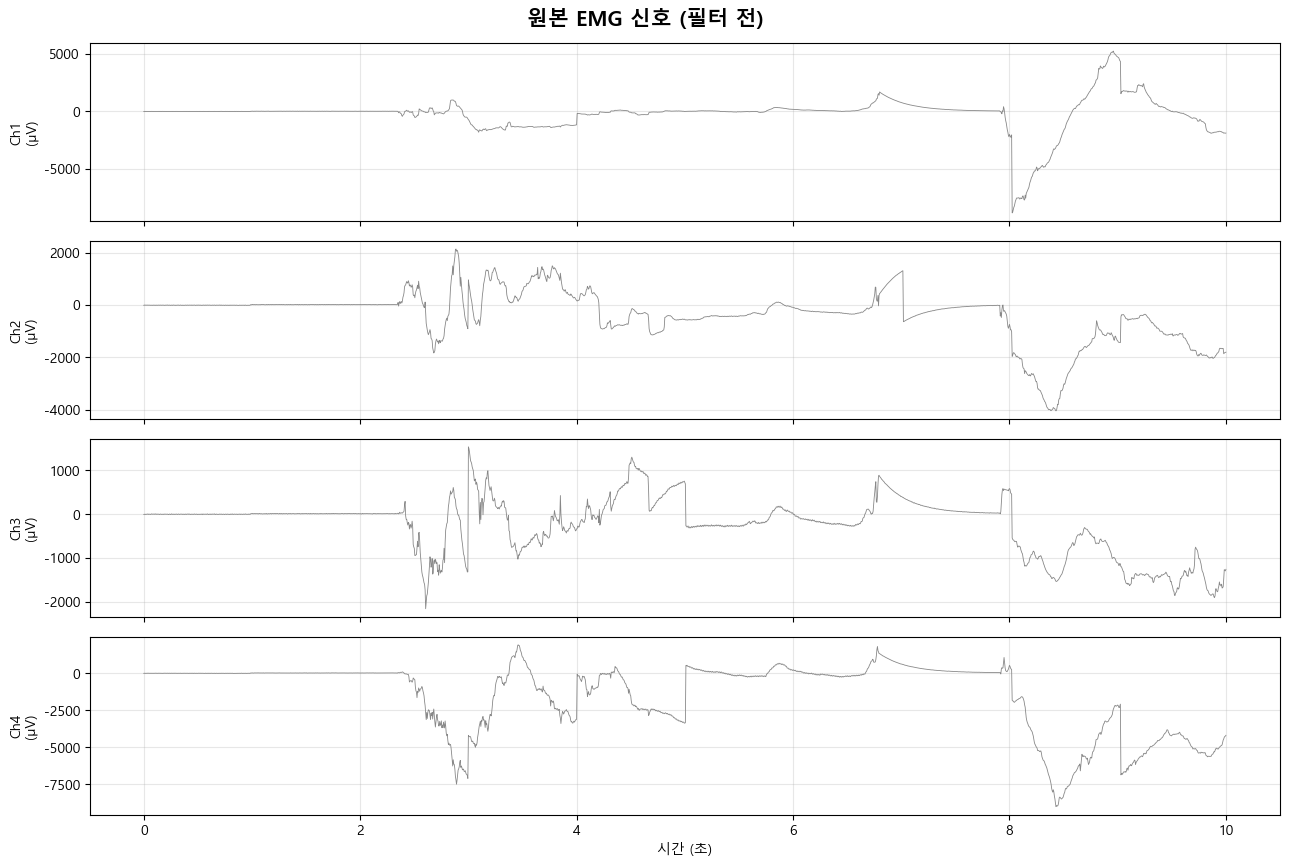

In [11]:
fig, axes = plt.subplots(N_CH, 1, figsize=(13, 2.2 * N_CH), sharex=True)
fig.suptitle('원본 EMG 신호 (필터 전)', fontsize=15, fontweight='bold')

for i in range(N_CH):
    axes[i].plot(t, emg[i], linewidth=0.6, color='#888888')
    axes[i].set_ylabel(f'Ch{i+1}\n(µV)')
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel('시간 (초)')
plt.tight_layout()
plt.show()

---
# 9단계 · 필터링

EMG 에서 쓸모 있는 성분만 남기고 나머지를 걷어냅니다.

### ① 대역통과 필터 (Bandpass) — 20~95 Hz

| 차단 | 이유 |
| --- | --- |
| **20 Hz 아래** 제거 | DC 오프셋, 전극 움직임 잡음(motion artifact) |
| **95 Hz 위** 제거 | 고주파 잡음 |

20 Hz 는 근전도 분야의 표준 저역 차단 주파수입니다.
움직임 잡음은 대부분 20 Hz 아래에 몰려 있습니다.

### ② 노치 필터 (Notch) — 60 Hz

한국 전원 주파수인 **60 Hz** 만 콕 집어 제거합니다.
(유럽·일본 동부는 50 Hz)

### ⚠️ 왜 95 Hz 인가 — 나이퀴스트 한계

EMG 는 원래 **450 Hz** 까지 성분이 있고, 에너지는 50~150 Hz 부근에 가장 많습니다.
그런데 200 Hz 로 측정하면 **100 Hz 까지만** 표현할 수 있습니다 (나이퀴스트 = 200÷2).

경계값인 100 Hz 는 필터가 불안정해지므로 **95 Hz** 로 둡니다.
EMG 의 위쪽 절반은 못 보지만, **신호의 세기**를 쓰는 용도에는 충분합니다.

> 🧪 **해 볼 것**: `LOW` 값을 5, 20, 40 으로 바꿔가며 재실행해 보세요.
> 낮게 두면 움직임 잡음이 남고, 너무 높이면 신호까지 깎입니다.

In [12]:
# ---- 필터 설정 (바꿔가며 실험해 보세요) ----
LOW   = 20.0    # Hz, 이보다 낮은 성분 제거 (움직임 잡음)
HIGH  = 95.0    # Hz, 이보다 높은 성분 제거 (나이퀴스트 100Hz 회피)
NOTCH = 60.0    # Hz, 전원 잡음 (한국 60Hz / 유럽 50Hz)
ORDER = 4
# -------------------------------------------

b_bp, a_bp = sp_signal.butter(ORDER, [LOW / NYQUIST, HIGH / NYQUIST], btype='band')
b_no, a_no = sp_signal.iirnotch(NOTCH / NYQUIST, Q=30)

filtered = np.zeros_like(emg)
for i in range(N_CH):
    x = sp_signal.filtfilt(b_bp, a_bp, emg[i])   # 대역통과
    x = sp_signal.filtfilt(b_no, a_no, x)        # 노치
    filtered[i] = x

print(f'필터 적용 완료 : {LOW}-{HIGH} Hz 대역통과 + {NOTCH} Hz 노치')
print(f'나이퀴스트 주파수 : {NYQUIST} Hz  (이보다 높은 주파수는 볼 수 없음)')
print()
print('채널별 변화 (표준편차, µV)')
print('-' * 46)
print(f'{"채널":<8}{"필터 전":>14}{"필터 후":>14}')
print('-' * 46)
for i in range(N_CH):
    print(f'Ch{i+1:<7}{emg[i].std():>14.2f}{filtered[i].std():>14.2f}')
print('-' * 46)
print()
print('필터 후 표준편차가 크게 줄었다면, 그만큼 잡음이 많았다는 뜻입니다.')

필터 적용 완료 : 20.0-95.0 Hz 대역통과 + 60.0 Hz 노치
나이퀴스트 주파수 : 100.0 Hz  (이보다 높은 주파수는 볼 수 없음)

채널별 변화 (표준편차, µV)
----------------------------------------------
채널                필터 전          필터 후
----------------------------------------------
Ch1             1546.51        109.43
Ch2              941.77         56.37
Ch3              625.27         59.45
Ch4             2332.59        126.62
----------------------------------------------

필터 후 표준편차가 크게 줄었다면, 그만큼 잡음이 많았다는 뜻입니다.


---
# 10단계 · 필터 전후 비교

같은 신호를 겹쳐 그려 필터가 무엇을 걷어냈는지 눈으로 확인합니다.

회색이 원본, 파란색이 필터 후입니다.
필터 후 신호가 0을 중심으로 정렬되고, 힘준 구간만 두꺼워지는 것이 보여야 합니다.

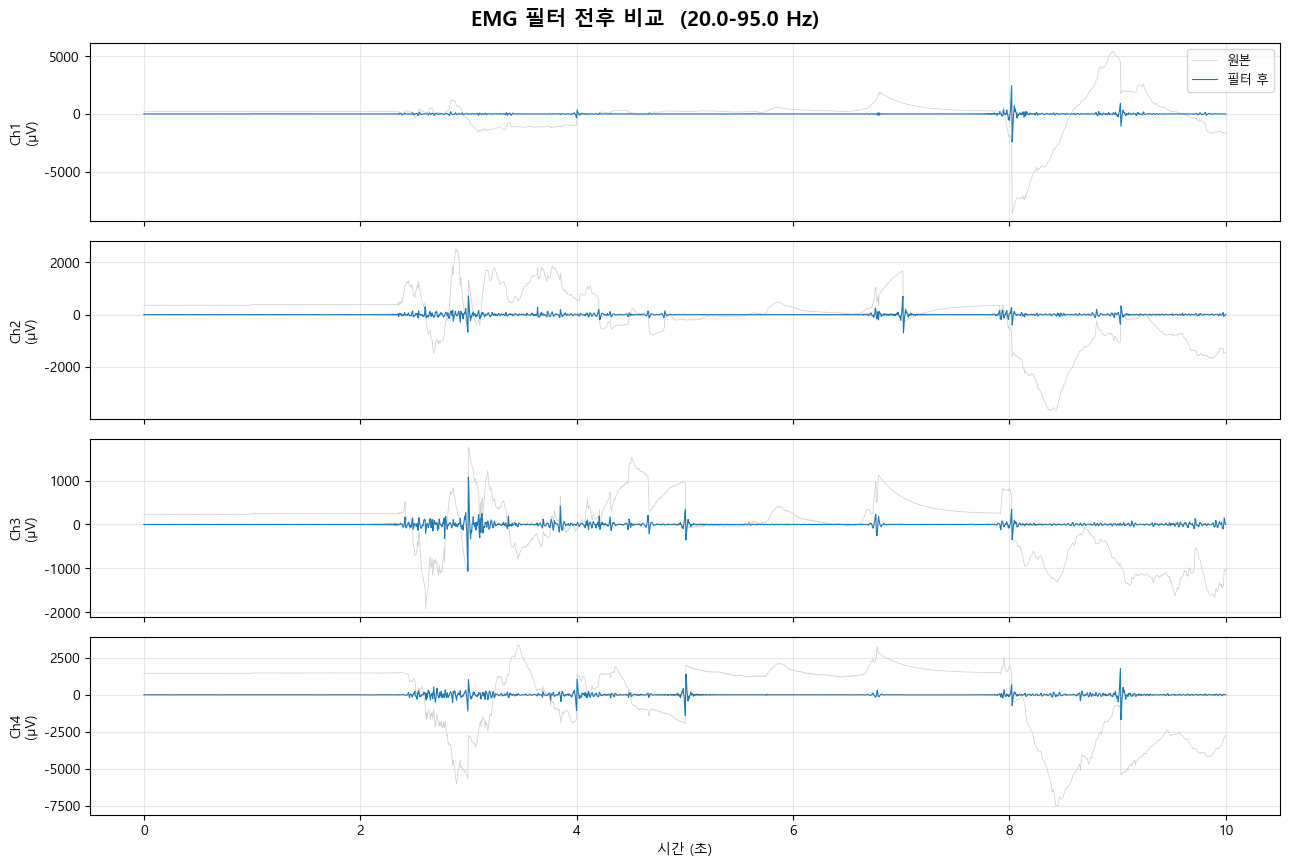

In [13]:
fig, axes = plt.subplots(N_CH, 1, figsize=(13, 2.2 * N_CH), sharex=True)
fig.suptitle(f'EMG 필터 전후 비교  ({LOW}-{HIGH} Hz)', fontsize=15, fontweight='bold')

for i in range(N_CH):
    axes[i].plot(t, emg[i] - emg[i].mean(), linewidth=0.5,
                 color='#cccccc', label='원본')
    axes[i].plot(t, filtered[i], linewidth=0.8,
                 color='#1f77b4', label='필터 후')
    axes[i].set_ylabel(f'Ch{i+1}\n(µV)')
    axes[i].grid(alpha=0.3)
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('시간 (초)')
plt.tight_layout()
plt.show()

---
# 11단계 · RMS — 근육이 얼마나 힘을 쓰는가

**RMS(제곱평균제곱근)** 는 신호가 얼마나 강한지를 하나의 숫자로 나타냅니다.

$$\text{RMS} = \sqrt{\frac{1}{N}\sum_{i=1}^{N} x_i^2}$$

EMG 는 0을 중심으로 위아래로 진동하므로 그냥 평균을 내면 0에 가깝습니다.
제곱해서 부호를 없앤 뒤 평균을 내야 **실제 활동량**이 나옵니다.

**왜 중요한가**: 근육에 힘을 줄수록 RMS 가 뚜렷하게 올라갑니다.
그래서 *RMS 가 기준값을 넘으면 모터를 움직인다* 같은 제어가 가능합니다.
2차시에서 이 값을 그대로 머신러닝 입력으로 씁니다.

아래는 **짧은 구간마다 RMS를 계산**해서 시간에 따라 힘이 어떻게 변하는지 봅니다.

> 🧪 **해 볼 것**: 수집할 때 약하게 → 중간 → 세게 순서로 힘을 줬다면,
> RMS 가 계단처럼 올라가는 것이 보일 것입니다.

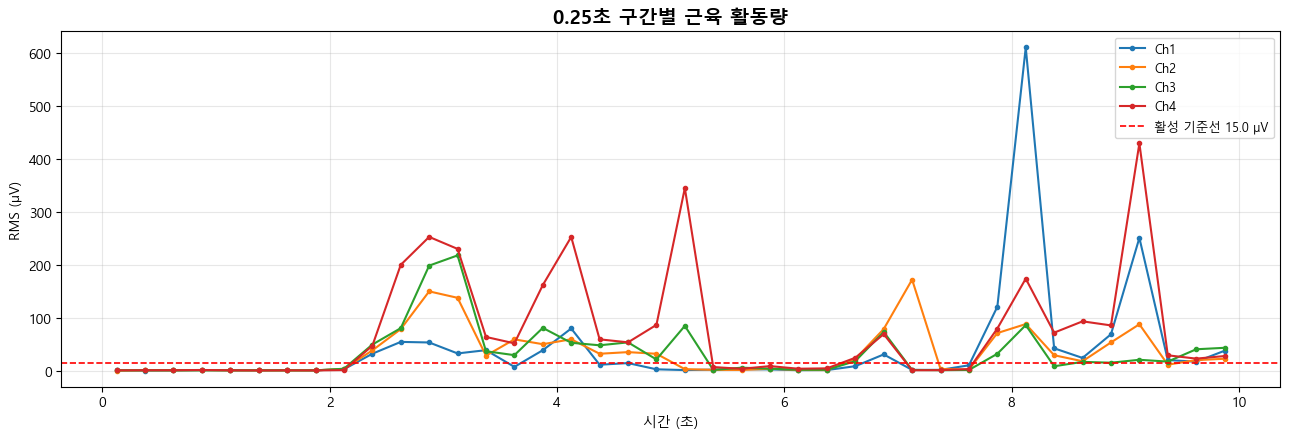

채널별 평균 RMS
------------------------------------------------
  Ch1 :   41.79 µV   활성 구간 18/40
  Ch2 :   36.11 µV   활성 구간 22/40
  Ch3 :   34.86 µV   활성 구간 22/40
  Ch4 :   74.71 µV   활성 구간 23/40

힘을 준 채널의 RMS 가 확실히 높다면 전극이 잘 붙은 것입니다.
모든 채널이 비슷하다면 전극 위치를 조정해 보세요.


In [14]:
WINDOW_SEC = 0.25                      # RMS 계산 구간 길이 (초)
win        = int(FS * WINDOW_SEC)
n_win      = filtered.shape[1] // win

rms      = np.zeros((N_CH, n_win))
rms_time = (np.arange(n_win) + 0.5) * WINDOW_SEC

for i in range(N_CH):
    for w in range(n_win):
        seg = filtered[i, w * win:(w + 1) * win]
        rms[i, w] = np.sqrt(np.mean(seg ** 2))

# 활성 판정 기준 - 쉬고 있을 때 RMS 보다 조금 높게 잡는다
THRESHOLD = 15.0   # µV

fig, ax = plt.subplots(figsize=(13, 4.5))
for i in range(N_CH):
    ax.plot(rms_time, rms[i], marker='o', markersize=3, label=f'Ch{i+1}')

ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.2,
           label=f'활성 기준선 {THRESHOLD} µV')
ax.set_xlabel('시간 (초)')
ax.set_ylabel('RMS (µV)')
ax.set_title(f'{WINDOW_SEC}초 구간별 근육 활동량', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('채널별 평균 RMS')
print('-' * 48)
for i in range(N_CH):
    over = int(np.sum(rms[i] > THRESHOLD))
    print(f'  Ch{i+1} : {rms[i].mean():7.2f} µV   활성 구간 {over}/{n_win}')
print()
print('힘을 준 채널의 RMS 가 확실히 높다면 전극이 잘 붙은 것입니다.')
print('모든 채널이 비슷하다면 전극 위치를 조정해 보세요.')

---
# 12단계 · 주파수 분석 — 근피로 지표

지금까지는 *시간에 따라* 신호를 봤습니다.
이번에는 **어떤 주파수 성분이 얼마나 들어있는지** 봅니다. (Welch 방법)

### EMG 에서 주파수가 왜 중요한가

근육이 **피로해지면 신호의 주파수가 내려갑니다.**
피로한 근섬유는 전도 속도가 느려지기 때문입니다.
그래서 근전도 분야에서는 다음 두 지표를 씁니다.

| 지표 | 뜻 | 피로하면 |
| --- | --- | --- |
| **중앙주파수 (MDF)** | 파워를 절반으로 나누는 주파수 | **내려간다** ↓ |
| **평균주파수 (MNF)** | 파워로 가중평균한 주파수 | **내려간다** ↓ |

힘의 세기는 **RMS**(11단계)로 보고, 피로는 **MDF/MNF**로 봅니다.
서로 다른 것을 알려주는 두 개의 창입니다.

### ⚠️ 이 보드의 한계를 알고 보세요

EMG 의 에너지는 보통 **50~150 Hz** 에 가장 많은데,
이 보드는 **100 Hz 까지만** 볼 수 있습니다.
따라서 여기서 구한 MDF/MNF 는 **실제보다 낮게** 나옵니다.

절대값을 논문 값과 비교하는 것은 의미가 없지만,
**같은 조건에서 시간에 따라 어떻게 변하는지** 보는 데는 유효합니다.

> 🧪 **근피로 실험**: 주먹을 **최대한 세게 30초 이상 계속** 쥐고 수집해 보세요.
> 시간이 갈수록 MDF 가 내려가는 것을 확인할 수 있습니다.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

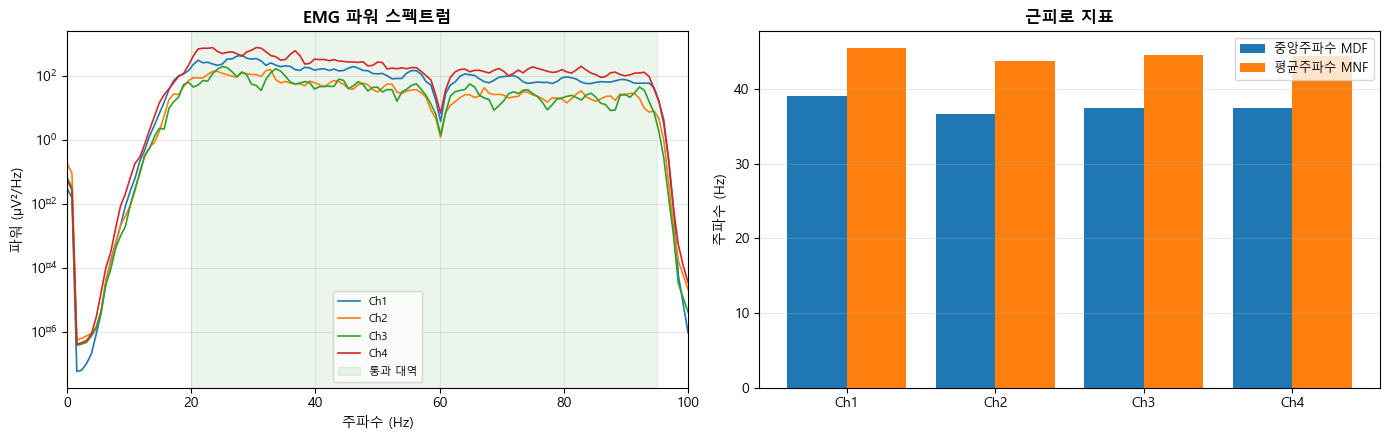

채널별 주파수 지표
----------------------------------------------------
채널            MDF (Hz)      MNF (Hz)
----------------------------------------------------
Ch1                39.1          45.5
Ch2                36.7          43.8
Ch3                37.5          44.6
Ch4                37.5          44.4
----------------------------------------------------

같은 근육을 반복 측정하며 이 값이 내려가면 피로가 쌓였다는 뜻입니다.
(이 보드는 100 Hz 까지만 보므로 절대값은 실제보다 낮게 나옵니다)


In [15]:
nperseg = min(256, filtered.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ---------- 왼쪽: 파워 스펙트럼 ----------
for i in range(N_CH):
    f, pxx = sp_signal.welch(filtered[i], fs=FS, nperseg=nperseg)
    axes[0].semilogy(f, pxx, linewidth=1.2, label=f'Ch{i+1}')

axes[0].axvspan(LOW, HIGH, color='green', alpha=0.08, label='통과 대역')
axes[0].set_xlabel('주파수 (Hz)')
axes[0].set_ylabel('파워 (µV²/Hz)')
axes[0].set_title('EMG 파워 스펙트럼', fontweight='bold')
axes[0].set_xlim(0, NYQUIST)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, which='both')

# ---------- 오른쪽: 중앙/평균 주파수 ----------
mdf_list, mnf_list = [], []
for i in range(N_CH):
    f, pxx = sp_signal.welch(filtered[i], fs=FS, nperseg=nperseg)
    m = (f >= LOW) & (f <= HIGH)          # 통과 대역 안에서만 계산
    fb, pb = f[m], pxx[m]
    df_f = fb[1] - fb[0]

    cum   = np.cumsum(pb) * df_f          # 누적 파워
    total = cum[-1]
    mdf = fb[np.searchsorted(cum, total / 2)] if total > 0 else 0.0   # 중앙주파수
    mnf = float(np.sum(fb * pb) * df_f / total) if total > 0 else 0.0 # 평균주파수
    mdf_list.append(mdf)
    mnf_list.append(mnf)

x = np.arange(N_CH)
axes[1].bar(x - 0.2, mdf_list, width=0.4, label='중앙주파수 MDF')
axes[1].bar(x + 0.2, mnf_list, width=0.4, label='평균주파수 MNF')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Ch{i+1}' for i in range(N_CH)])
axes[1].set_ylabel('주파수 (Hz)')
axes[1].set_title('근피로 지표', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('채널별 주파수 지표')
print('-' * 52)
print(f'{"채널":<8}{"MDF (Hz)":>14}{"MNF (Hz)":>14}')
print('-' * 52)
for i in range(N_CH):
    print(f'Ch{i+1:<7}{mdf_list[i]:>14.1f}{mnf_list[i]:>14.1f}')
print('-' * 52)
print()
print('같은 근육을 반복 측정하며 이 값이 내려가면 피로가 쌓였다는 뜻입니다.')
print(f'(이 보드는 {NYQUIST:.0f} Hz 까지만 보므로 절대값은 실제보다 낮게 나옵니다)')

---
# 13단계 · 저장

원본과 필터링된 신호를 **CSV**로 저장합니다.
Excel, MATLAB, 파이썬 어디서든 다시 열어 볼 수 있습니다.

저장 위치는 프로젝트의 `outputs/` 폴더입니다.

In [ ]:
out_dir = Path('..') / 'outputs'
out_dir.mkdir(exist_ok=True)

stamp = datetime.now().strftime('%Y%m%d_%H%M%S')

save_df = df.copy()
for i in range(N_CH):
    save_df[f'Ch{i+1}_filtered'] = filtered[i]

# 어느 보드로 측정했는지 파일에 기록해 둔다
_board = globals().get('CONNECTED_BOARD', {})
save_df['board_name'] = _board.get('name', 'unknown')
save_df['board_mac']  = _board.get('mac', 'unknown')

_tag = (_board.get('name') or 'unknown').replace(' ', '')
csv_path = out_dir / f'ganglion_{_tag}_{stamp}.csv'
save_df.to_csv(csv_path, index=False)

print('저장 완료')
print(f'  파일  : {csv_path.resolve()}')
print(f'  크기  : {save_df.shape[0]} 행 x {save_df.shape[1]} 열')
print(f'  기간  : {save_df.shape[0] / FS:.2f} 초')
print()
print('열 구성:')
print(f'  time_sec           시간 (초)')
print(f'  Ch1..Ch{N_CH}            원본 (µV)')
print(f'  Ch1_filtered..     필터 후 (µV)')
print(f'  board_name         측정에 쓴 보드 광고명')
print(f'  board_mac          그 보드의 MAC 주소')
print()
print('나중에 다시 불러오기:')
print(f"  df = pd.read_csv(r'{csv_path.name}')")

---
# 14단계 · 연결 해제 ⚠️ **꼭 실행하세요**

보드와의 연결을 정리합니다.

이걸 건너뛰면 동글이 계속 점유된 상태로 남아서,
**다음 실행이나 OpenBCI GUI가 연결되지 않습니다.**

> 노트북 커널을 재시작해도 정리됩니다. 연결이 이상하면 커널 재시작 후 다시 시도하세요.

In [16]:
try:
    if board.is_prepared():
        board.release_session()
        print('연결 해제 완료. 동글이 사용 가능한 상태입니다.')
    else:
        print('이미 해제되어 있습니다.')
except Exception as e:
    print(f'해제 중 문제 발생: {e}')
    print('노트북 커널을 재시작하면 정리됩니다.')

연결 해제 완료. 동글이 사용 가능한 상태입니다.


---
# 정리

## 오늘 배운 흐름

```
팔 근육 EMG (4채널, 200Hz)
     ↓  BLE
BLED112 동글 (COM 포트)
     ↓  BrainFlow
행렬 (채널 x 시간)
     ↓  필터 (20-95Hz + 60Hz 노치)
깨끗한 EMG
     ↓
  ┌──────────┬──────────────┐
  RMS          MDF / MNF
(근육 활동량)   (근피로 지표)
     ↓
   CSV 저장
```

## 핵심 개념

| 개념 | 의미 |
| --- | --- |
| EMG | 근육이 수축할 때 나오는 전기 신호 |
| 샘플링 레이트 | 초당 측정 횟수 (Ganglion = 200 Hz) |
| 나이퀴스트 | 볼 수 있는 최대 주파수 = 200 ÷ 2 = 100 Hz |
| 대역통과 20-95Hz | 움직임 잡음(저주파)과 고주파 잡음 제거 |
| 노치 60Hz | 전원 잡음만 콕 집어 제거 |
| RMS | 근육 활동량 → 임계값 제어에 사용 |
| MDF / MNF | 근피로 지표. 피로하면 내려간다 |

---

## 과제 아이디어

**기초**
1. 힘을 약·중·강으로 나눠 주고 RMS 가 단계별로 올라가는지 확인
2. `LOW` 를 5, 20, 40 Hz 로 바꿔가며 움직임 잡음이 어떻게 달라지는지 기록
3. 노치 필터를 껐을 때 스펙트럼의 60 Hz 부근 관찰

**응용**
4. 주먹을 30초 이상 세게 쥐고 측정 → 시간에 따른 MDF 변화(근피로) 그리기
5. 팔뚝 안쪽/바깥쪽 근육에 전극을 옮겨 붙이며 채널별 RMS 비교
6. 손목을 굽힐 때와 펼 때 어느 채널이 활성인지 지도 그리기

**다음 시간**
7. 이 RMS 값을 머신러닝에 넣어 **가위·바위·보를 자동 판별** (2차시)

---

## 문제가 생기면

| 증상 | 확인할 것 |
| --- | --- |
| 연결 실패 | **OpenBCI GUI 종료** (가장 흔함) |
| 포트를 못 찾음 | 동글 다시 꽂기 → 2단계 재실행 |
| 샘플 0개 | 보드 전원, 배터리, 전극 연결 |
| 여러 보드가 켜져 있음 | 「내 보드 확인」 셀 안내대로 |
| 힘을 줘도 신호가 안 변함 | 전극 밀착, 기준 전극 위치(뼈 위) 확인 |
| 신호가 온통 잡음 | 케이블 흔들림, 전극 접촉, 전원 어댑터 근처 회피 |
| 계속 이상함 | 커널 재시작 → 처음부터 다시 |

---

*재활재생개론 · OpenBCI Ganglion 실습 1 (EMG)*